In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
%matplotlib inline
import geopandas as gpd
import xdem
import os
import rasterio as rio
from rasterio.plot import show
import glob
from concurrent.futures import ThreadPoolExecutor
import requests
import shapely
from tqdm import tqdm
import json
from shapely.geometry import shape
from rasterio.mask import mask
from rasterio.crs import CRS
import rioxarray as rxr
from shapely import wkt
from pyproj import Proj, transform

In [3]:
# Every time you change something within the code cell, run it once more to update the variable.

BOUNDS = [38.212642, -78.583853, 36.580608, -82.061026] # In decimal coordinate form.  Format: [N, E, S, W].  Select the smallest area possible in your analyses for maximum resoultion!  

API_KEY = '9086887f175d33aa72eda767f5b1e9cd' # Get your API key from opentopography.org.  Students get higher resolution data!

DEM_DATASET = 'USGS30m' # Options are USGS30m, USGS10m, & USGS1m.  Be warned!  As resolution goes up, available download area goes down.

PROJ_TITLE = 'BR' # Create a succinct name with no spaces or leading digits to represent your project file for future exports.

PATH = os.getcwd()

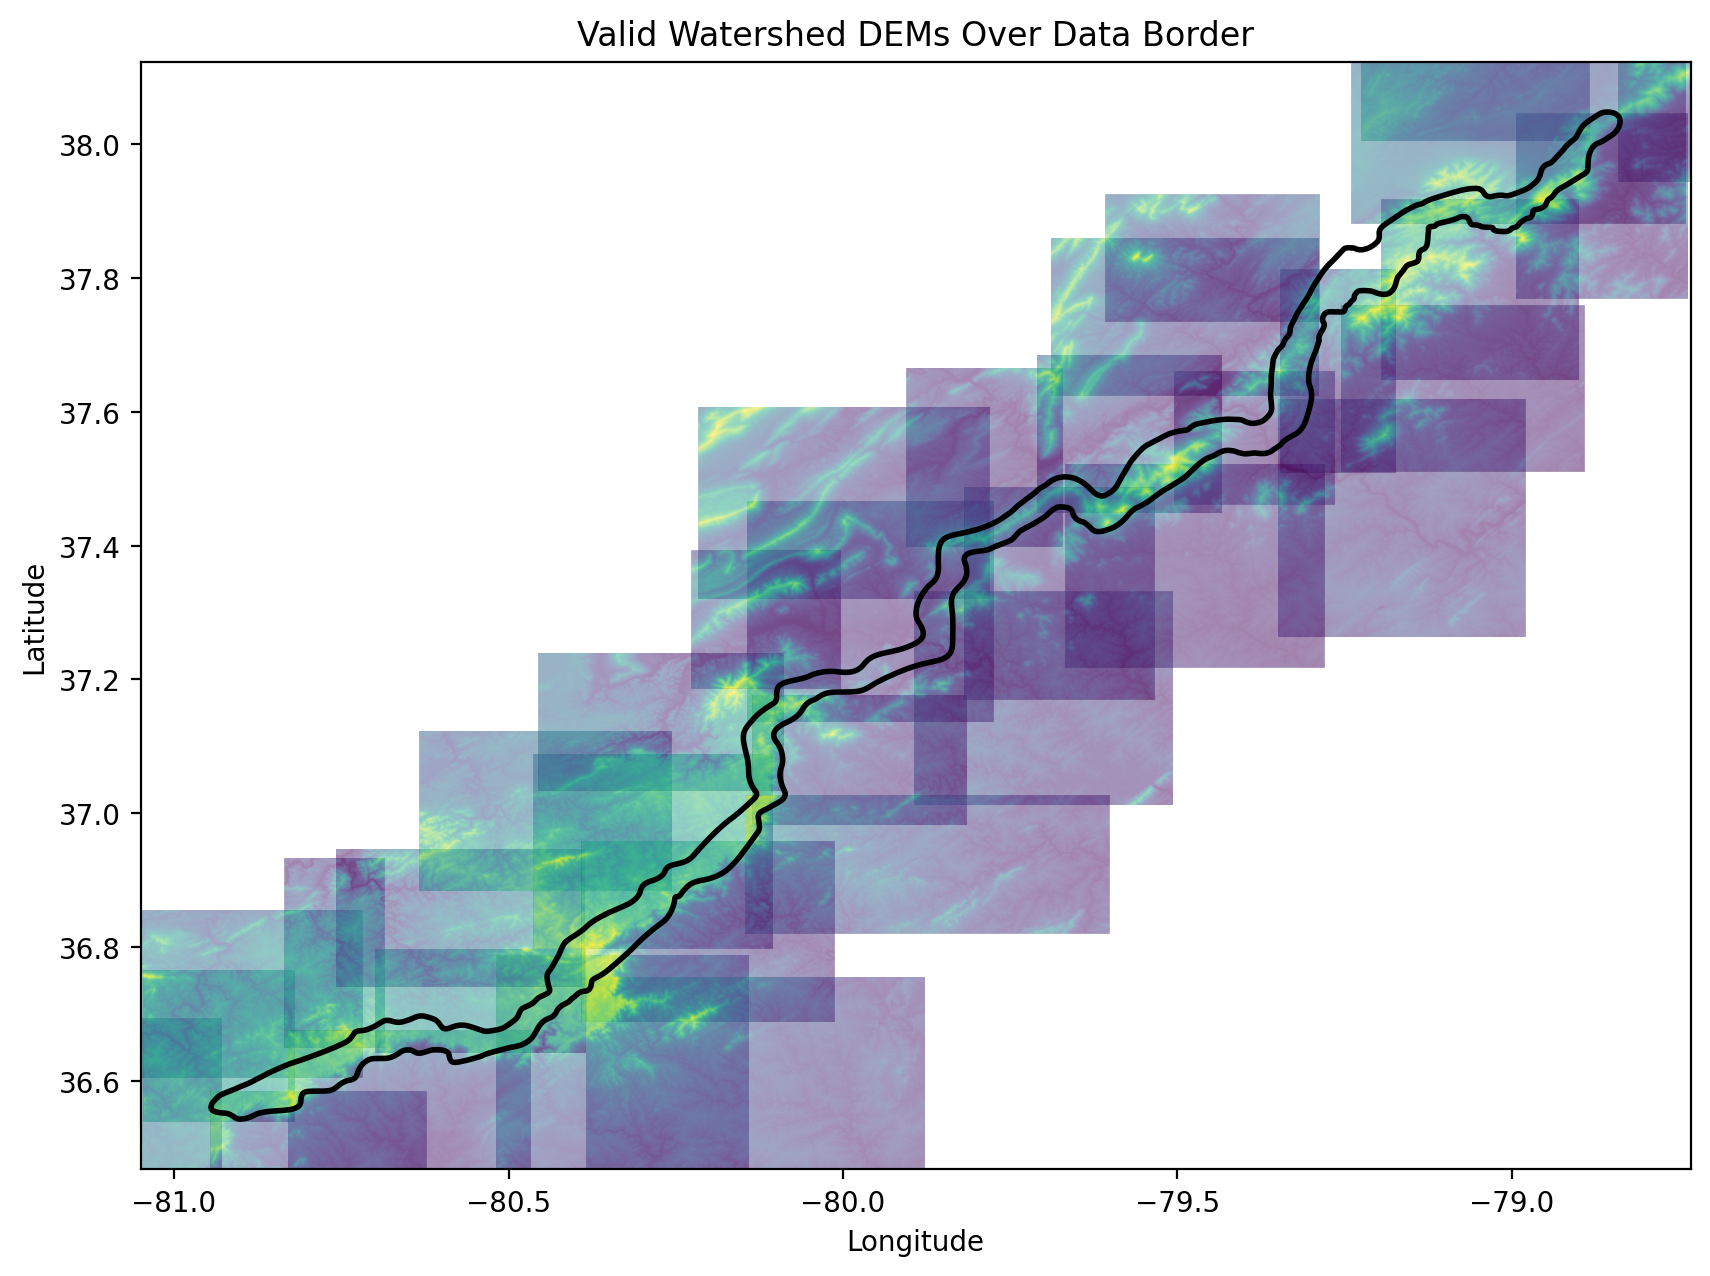

In [10]:
wsheds = glob.glob(f'{PATH}/{PROJ_TITLE}/wshed_dems/*.tiff')
wsheds_valid = []
border = gpd.read_file('/sciclone/home/ntlewis/Nick-Lewis-Research/working_files/jupyter_proto/BR/br_shps/border.shp')
border.to_crs(epsg=4326, inplace=True)
fig, ax = plt.subplots(figsize=(10,10), dpi=200)
border.plot(ax=ax, facecolor='none', edgecolor='black', linewidth=2)
ax.set_xlim(plt.xlim())
ax.set_ylim(plt.ylim())
for wshed in wsheds:
    dem = rio.open(wshed)
    is_in = shapely.intersects(border.geometry, shapely.geometry.box(*dem.bounds))
    if is_in[0]:
        show(dem, ax=ax, alpha=0.5)
        wsheds_valid.append(wshed)
plt.title('Valid Watershed DEMs Over Data Border')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.show()

In [14]:
print(f'Number of valid watershed DEMs: {len(wsheds_valid)}')
print(f'Total watershed DEMs found: {len(wsheds)}')
print(f'Deleting invalid watershed DEMs...')
dir = os.listdir(f'{PATH}/{PROJ_TITLE}/wshed_dems/')
for file in dir:
    filepath = f'{PATH}/{PROJ_TITLE}/wshed_dems/{file}'
    if filepath not in wsheds_valid:
        os.remove(filepath)
print('Invalid watershed DEMs deleted.')

Number of valid watershed DEMs: 35
Total watershed DEMs found: 165
Deleting invalid watershed DEMs...
Invalid watershed DEMs deleted.
